Dit0_v     = 8.907e+13
Ev_trap    = 2.552e-02
Dit0_c     = 1.086e+14
Ec_trap    = 3.954e-02
Dit0_g     = 2.400e+12
E0         = 5.000e-01
sigma      = 4.000e-01


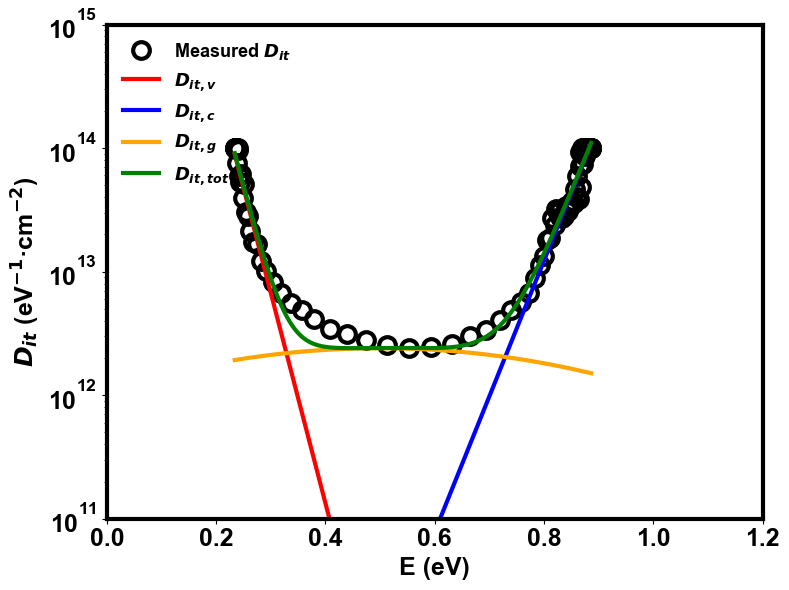

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 设置字体为 Times New Roman 并加粗
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.unicode_minus'] = False
# 重新读取上传的文件
file_path = 'Wafer_Dit_Modelling_UV20h_1.xlsx'
df = pd.read_excel(file_path)

# 提取数据
E_data = df['Et-Ev'].values
Dit_exp = df['UV20h'].values

Ev = min(E_data)
Ec = max(E_data)

# 重新定义 log 拟合函数
def log_Dit_model(E, Dit0_v, Ev_trap, Dit0_c, Ec_trap, Dit0_g, E0, sigma):
    Dit_v = Dit0_v * np.exp(-(E - Ev) / Ev_trap)
    Dit_c = Dit0_c * np.exp(-(Ec - E) / Ec_trap)
    Dit_g = Dit0_g * np.exp(-((E - E0)**2) / (2 * sigma**2))
    return np.log10(Dit_v + Dit_c + Dit_g)

# 对数形式的实验数据
log_Dit_exp = np.log10(Dit_exp)

# 使用中等高斯宽度的拟合设置
bounds = (
    [1e10, 0.015, 1e10, 0.01, 1e10, 0.5, 0.2],
    [1e15, 0.05,   1e15, 0.05,   2.4e12, 0.6, 0.4]
)
p0 = [1e13, 0.04, 1e13, 0.04, 1e10, 0.55, 0.25]

# 重新拟合
popt, _ = curve_fit(log_Dit_model, E_data, log_Dit_exp, p0=p0, bounds=bounds)

# 更密集的能量点用于平滑绘图
E_dense = np.linspace(min(E_data), max(E_data), 1000)

# 拟合模型在密集点上的计算
Dit_v = popt[0] * np.exp(-(E_dense - Ev) / popt[1])
Dit_c = popt[2] * np.exp(-(Ec - E_dense) / popt[3])
Dit_g = popt[4] * np.exp(-((E_dense - popt[5])**2) / (2 * popt[6]**2))
Dit_total = Dit_v + Dit_c + Dit_g

# 绘图
plt.figure(figsize=(8, 6))
plt.semilogy(
    E_data, Dit_exp,
    'o', linestyle='None',
    markerfacecolor='none',
    markeredgecolor='k',
    markeredgewidth=3,   # 边框加粗
    markersize=12,         # 点放大
    label='Measured $D_{it}$'
)
plt.semilogy(E_dense, Dit_v, 'r-', linewidth=3, label=r'$D_{it,v}$')
plt.semilogy(E_dense, Dit_c, 'b-', linewidth=3, label=r'$D_{it,c}$')
plt.semilogy(E_dense, Dit_g, 'orange', linewidth=3, label=r'$D_{it,g}$')
plt.semilogy(E_dense, Dit_total, 'g-', linewidth=3, label=r'$D_{it,tot}$')

plt.xlabel('E (eV)', fontweight='bold', fontsize=18)
plt.ylabel(r'$D_{it}$ (eV$^{-1}$·cm$^{-2}$)', fontweight='bold', fontsize=18)
# plt.title('Gaussian Fitting of $D_{it}$ (After UV)', fontweight='bold', fontsize=20)
plt.legend(
    loc='upper left',
    frameon=False,
    prop={
        'family': 'Arial',
        'weight': 'bold',
        'size': 13   # 在这里指定字体大小
    }
)
plt.tick_params(axis='both', which='major', labelsize=18)  # 设置坐标轴数值字体大小为12，可按需调整

# 加粗边框
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(3)

plt.grid(False)
plt.xlim(0, 1.2)
plt.ylim(1e11, 1e15)
plt.tight_layout()

# 保存图像
plt.savefig('gaussian_fit_uv20h.png', dpi=300)  # 保存为PNG格式，300 dpi清晰度
plt.savefig('gaussian_fit_uv20h.pdf')        # 如果你想保存为PDF格式


# 输出拟合参数
param_names = ['Dit0_v', 'Ev_trap', 'Dit0_c', 'Ec_trap', 'Dit0_g', 'E0', 'sigma']
for name, val in zip(param_names, popt):
    print(f'{name:<10} = {val:.3e}')
